In [13]:
import os
import requests
import json
from dotenv import load_dotenv
import requests_cache
import re, time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    roc_auc_score
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor, XGBClassifier

In [22]:
# load .env file, get API key
#load_dotenv()
#API_KEY = os.getenv("api_key")

# make sure API key is available
#if not API_KEY:
    #raise ValueError("no API key found")

# set up a cached session
session = requests_cache.CachedSession('output/steam_api_cache', expire_after=86400)

In [24]:
# sample output
def fetch_steam_app_data(app_id: int) -> dict:
    """
    Fetch detailed information about a Steam application using the Storefront API.
    """
    
    # define the target API endpoint
    url = "https://store.steampowered.com/api/appdetails"
    
    # construct query parameters for the GET request
    params = {
        "appids": app_id,
        "cc": "us",      # currency: USD
        "l": "english"   # language: English
    }
    
    try:

        # use cached session to sent request, timeout after 10 seconds
        response = session.get(url, params=params, timeout=10)
        response.raise_for_status()
        
        # parse the JSON response into a json
        raw_data = response.json()
        
        # check if the response contains valid data for the given app_id
        app_id_str = str(app_id)
        if app_id_str in raw_data and raw_data[app_id_str].get("success"):
            return raw_data[app_id_str]["data"]
        else:
            print(f"No valid data found for AppId:{app_id_str}")
            return None
            
    except requests.exceptions.RequestException as e:
        print(f"HTTP Request failed: {e}")
        return None


In [26]:
sample_output = fetch_steam_app_data(1091500)

with open("output/sample_app_data.json", "w") as f:
    json.dump(sample_output, f, indent=4)

In [40]:
# 1) 从 Steam 商店搜索页抓一批 appid
#    filter="topsellers" 可换成 "newandtrending" / "specials"
def get_appids(target=2000, pages=120, flt="topsellers"):
    s = requests.Session()
    s.headers.update({"User-Agent": "Mozilla/5.0"}) 

    appids, seen = [], set()
    for p in range(1, pages + 1):
        html = s.get(
            "https://store.steampowered.com/search/",
            params={"filter": flt, "page": p},
            timeout=30
        ).text

        # 搜索页里每个游戏条目都有 data-ds-appid="1091500"
        # 有时会是 "123,456"（例如包含多个 appid），所以后面要 split(",")
        for x in re.findall(r'data-ds-appid="([\d,]+)"', html):
            for a in x.split(","):
                a = int(a)
                if a not in seen:
                    seen.add(a)
                    appids.append(a)
                    if len(appids) >= target:
                        return appids

        # 翻页限速
        time.sleep(0.5 + random.random() * 0.3)

    return appids

# 2) 429 限流自动重试：指数退避（1.2s, 2.4s, 4.8s...）+ 随机抖动
def safe_fetch(appid, tries=7, base=1.2):
    for i in range(tries):
        try:
            return fetch_steam_app_data(appid)
        except Exception as e:
            # 只对 429 处理，其它错误就跳过该游戏
            if "429" not in str(e):
                return None

            wait = base * (2 ** i) + random.random()
            print(f"[429] appid={appid} wait={wait:.1f}s (try {i+1}/{tries})")
            time.sleep(wait)
    return None


# 3) 主循环：抓 1000 个游戏，输出 JSONL（每行一个 sample.json 结构）
TARGET = 1000
OUT = "steam_1000.jsonl"

appids = get_appids(target=TARGET * 2, pages=120, flt="topsellers")
random.shuffle(appids)  # 打乱顺序，避免全部都是榜单前排类型

n = 0
with open(OUT, "w", encoding="utf-8") as f:
    for appid in appids:
        d = safe_fetch(appid)

        # 只保留真正的游戏（过滤 demo / dlc / application）
        if d and (d.get("type") or "").lower() == "game":
            f.write(json.dumps(d, ensure_ascii=False) + "\n") 
            n += 1
            if n >= TARGET:
                break

        time.sleep(1.0 + random.random() * 0.5)

print(f"Done. saved={n} -> {OUT}")

HTTP Request failed: 502 Server Error: Bad Gateway for url: https://store.steampowered.com/api/appdetails?appids=3228590&cc=us&l=english
HTTP Request failed: 502 Server Error: Bad Gateway for url: https://store.steampowered.com/api/appdetails?appids=2745870&cc=us&l=english
HTTP Request failed: 502 Server Error: Bad Gateway for url: https://store.steampowered.com/api/appdetails?appids=3315510&cc=us&l=english
HTTP Request failed: 502 Server Error: Bad Gateway for url: https://store.steampowered.com/api/appdetails?appids=3116890&cc=us&l=english
HTTP Request failed: 502 Server Error: Bad Gateway for url: https://store.steampowered.com/api/appdetails?appids=2948190&cc=us&l=english
HTTP Request failed: 502 Server Error: Bad Gateway for url: https://store.steampowered.com/api/appdetails?appids=2973290&cc=us&l=english
Done. saved=1000 -> steam_1000.jsonl


In [15]:

df = pd.read_json("steam_1000.jsonl", lines=True)

df.head()
print(df.columns.tolist())

# 提取价格字段
df["discount"] = df["price_overview"].apply(lambda x: x.get("discount_percent") if isinstance(x, dict) else None)
df["initial_price"] = df["price_overview"].apply(lambda x: x.get("initial")/100 if isinstance(x, dict) else None)
df["final_price"] = df["price_overview"].apply(lambda x: x.get("final")/100 if isinstance(x, dict) else None)

# 推荐数
df["recommendations"] = df["recommendations"].apply(lambda x: x.get("total") if isinstance(x, dict) else None)

df.head()

['type', 'name', 'steam_appid', 'required_age', 'is_free', 'controller_support', 'detailed_description', 'about_the_game', 'short_description', 'supported_languages', 'reviews', 'header_image', 'capsule_image', 'capsule_imagev5', 'website', 'pc_requirements', 'mac_requirements', 'linux_requirements', 'legal_notice', 'ext_user_account_notice', 'developers', 'publishers', 'demos', 'price_overview', 'packages', 'package_groups', 'platforms', 'metacritic', 'categories', 'genres', 'screenshots', 'movies', 'recommendations', 'achievements', 'release_date', 'support_info', 'background', 'background_raw', 'content_descriptors', 'ratings', 'drm_notice', 'dlc']


,type,name,steam_appid,required_age,is_free,controller_support,detailed_description,about_the_game,short_description,supported_languages,...,support_info,background,background_raw,content_descriptors,ratings,drm_notice,dlc,discount,initial_price,final_price
0,game,Saints Row IV: Re-Elected,206420,17,False,full,<strong><i>Fully Re-Elected – Saints Row IV Re...,<strong><i>Fully Re-Elected – Saints Row IV Re...,Experience the insane antics of Saints Row IV....,"English<strong>*</strong>, French, German, Ita...",...,"{'url': 'helpcenter.deepsilver.com', 'email': ''}",https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,"{'ids': [5], 'notes': 'The game contains viole...","{'esrb': {'rating': 'm', 'use_age_gate': 'true...",NaN,NaN,75.0,19.99,4.99
1,game,ARMORED CORE™ VI FIRES OF RUBICON™,1888160,13,False,NaN,<h1>Digital Deluxe Edition</h1><p><span class=...,Combining FromSoftware’s longstanding expertis...,A new action game based on the concept of the ...,"English<strong>*</strong>, French, Italian, Ge...",...,{'url': 'https://www.bandainamcoent.com/suppor...,https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,"{'ids': [2, 5], 'notes': None}","{'fpb': {'rating': '13', 'descriptors': 'LV (P...","Arxan, Easy Anti-Cheat",NaN,0.0,59.99,59.99
2,game,Tavern Talk - A Cozy Visual Novel,2076140,0,False,full,<h1>Pledge on Kickstarter &amp; grab FREE gift...,"<h2 class=""bb_tag"" > What to Expect</h2><p cla...",A cozy visual novel about running a tavern in ...,"English, German, Japanese, Simplified Chinese,...",...,"{'url': '', 'email': 'support@playtaverntalk.c...",https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,"{'ids': [], 'notes': None}","{'dejus': {'rating': 'l'}, 'usk': {'rating': '...",NaN,"[3268390, 4028280, 3244740, 3047170, 3047210, ...",40.0,17.99,10.79
3,game,Graviteam Tactics: Mius-Front,312980,0,False,NaN,Graviteam Tactics: Mius-Front - tactical batta...,Graviteam Tactics: Mius-Front - tactical batta...,Graviteam Tactics: Mius-Front - tactical batta...,"English, Russian",...,{'url': 'https://steamcommunity.com/groups/gra...,https://store.akamai.steamstatic.com/images/st...,https://store.akamai.steamstatic.com/images/st...,"{'ids': [], 'notes': None}","{'dejus': {'rating_generated': '1', 'rating': ...",NaN,"[2717580, 2476130, 2349300, 2443610, 1943790, ...",0.0,34.99,34.99
4,game,SONIC SUPERSTARS,2022670,0,False,full,<h1>Feature List</h1><p></p><br><h1>Digital De...,The <strong>SONIC SUPERSTARS Digital Deluxe Ed...,Adventure through the mystical Northstar Islan...,"English, French, Italian, German, Spanish - Sp...",...,"{'url': 'https://support.sega.com/hc/en-us', '...",https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,"{'ids': [], 'notes': None}","{'usk': {'rating': '6'}, 'oflc': {'rating': 'g...",Denuvo Anti-tamper,"[2376684, 2376680, 2376683, 2504600, 2376681, ...",70.0,59.99,17.99


In [16]:
# varaibles
df["log_rec"] = np.log1p(df["recommendations"])

df["discount_price"] = df["discount"] * df["initial_price"]

df["lang_count"] = df["supported_languages"].apply(
    lambda x: len(str(x).split(",")) if pd.notnull(x) else 0
)

df["genre_count"] = df["genres"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

df["dlc_count"] = df["dlc"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

df["supports_mac"] = df["platforms"].apply(
    lambda x: x.get("mac") if isinstance(x, dict) else 0
)

df["cat_count"] = df["categories"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

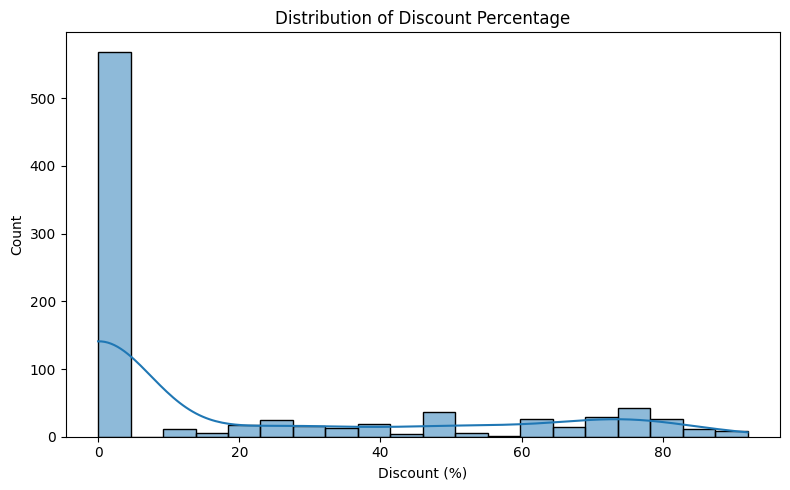

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["discount"].dropna(), bins=20, kde=True)
plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

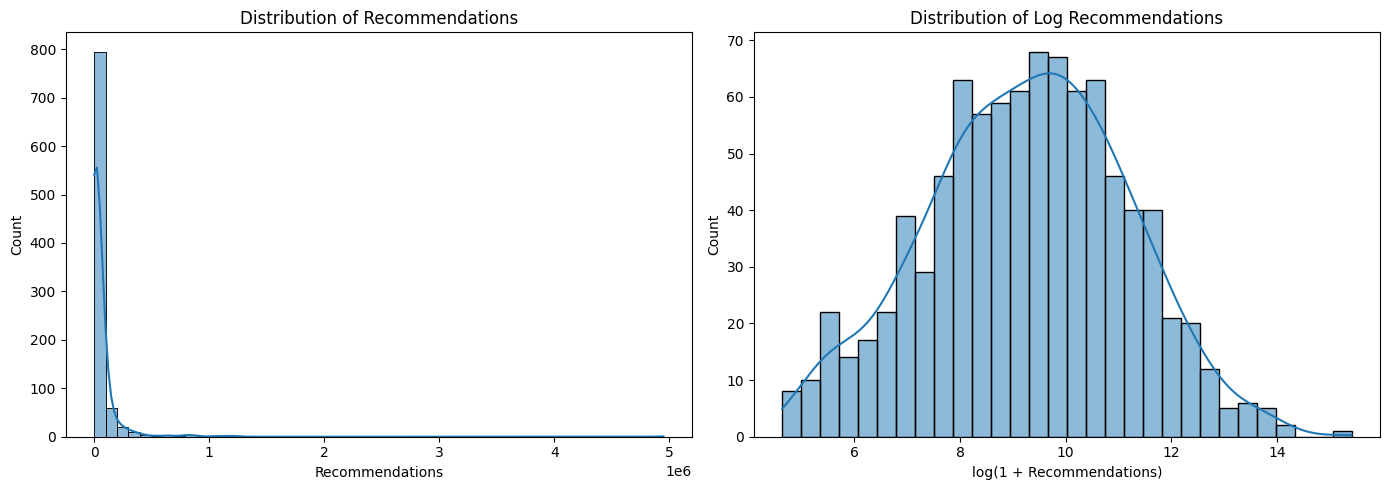

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw recommendations
sns.histplot(df["recommendations"].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Recommendations")
axes[0].set_xlabel("Recommendations")
axes[0].set_ylabel("Count")

# log recommendations
sns.histplot(df["log_rec"].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Log Recommendations")
axes[1].set_xlabel("log(1 + Recommendations)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

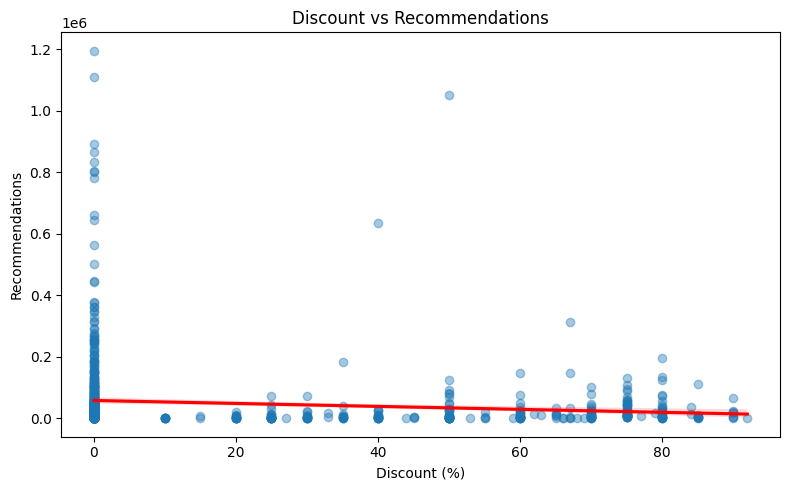

In [22]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="discount", y="recommendations", scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.title("Discount vs Recommendations")
plt.xlabel("Discount (%)")
plt.ylabel("Recommendations")
plt.tight_layout()
plt.show()

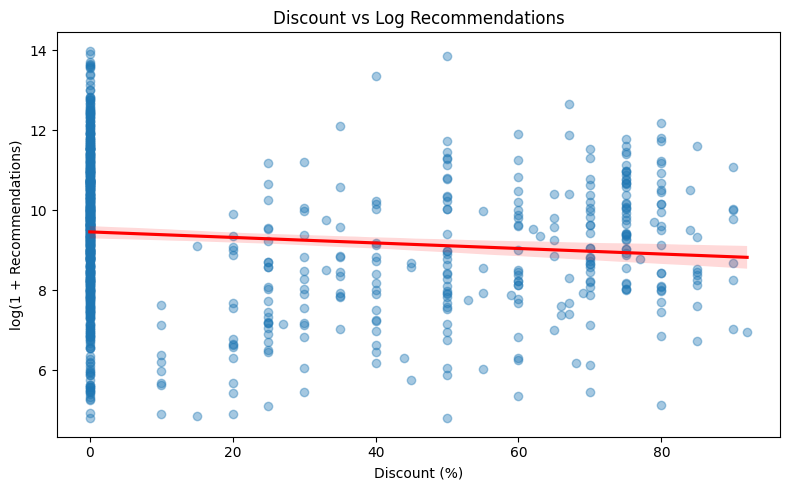

In [25]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="discount", y="log_rec", scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.title("Discount vs Log Recommendations")
plt.xlabel("Discount (%)")
plt.ylabel("log(1 + Recommendations)")
plt.tight_layout()
plt.show()

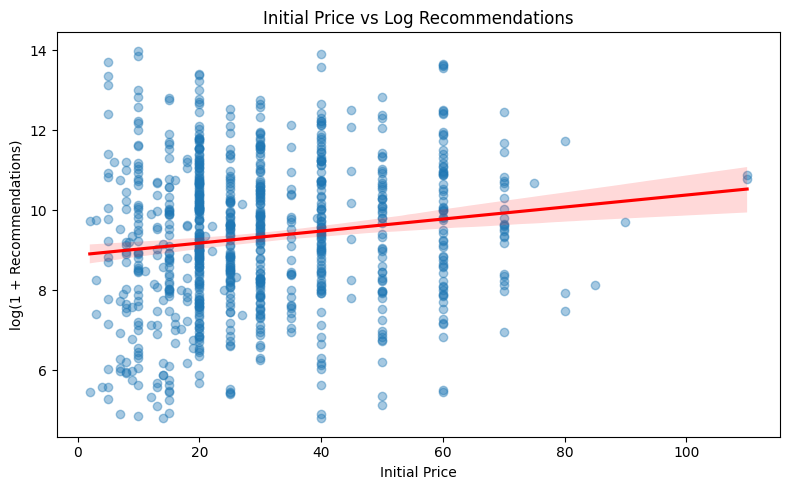

In [29]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x="initial_price",
    y="log_rec",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)
plt.title("Initial Price vs Log Recommendations")
plt.xlabel("Initial Price")
plt.ylabel("log(1 + Recommendations)")
plt.tight_layout()
plt.show()

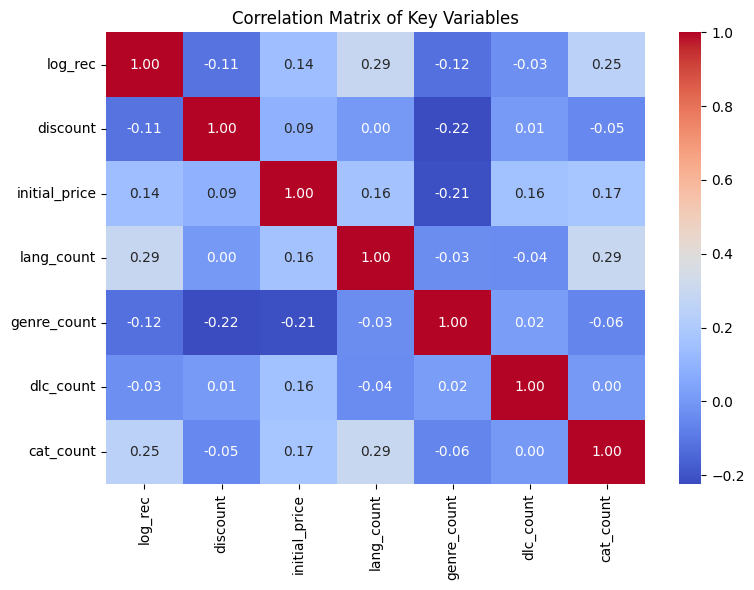

In [43]:
corr_cols = [
    "log_rec",
    "discount",
    "initial_price",
    "lang_count",
    "genre_count",
    "dlc_count",
    "cat_count"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Variables")

plt.tight_layout()
plt.show()

In [33]:
import statsmodels.api as sm

X = df[
    [
        "discount",
        "initial_price",
        "discount_price",
        "lang_count",
        "genre_count",
        "dlc_count",
        "cat_count"
    ]
]

y = df["log_rec"]

X = sm.add_constant(X)

model = sm.OLS(y, X, missing="drop").fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_rec   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     19.38
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.92e-24
Time:                        12:57:46   Log-Likelihood:                -1663.3
No. Observations:                 856   AIC:                             3343.
Df Residuals:                     848   BIC:                             3381.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              8.0657      0.239     33.

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = [
    "discount",
    "initial_price",
    "discount_price",
    "lang_count",
    "genre_count",
    "dlc_count",
    "cat_count",
]

ml_df = df[features + ["log_rec"]].dropna()

X = ml_df[features]
y = ml_df["log_rec"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred, squared=False))

R2: 0.10221670495246549
RMSE: 1.5649494611899717


D:\anaconda\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [36]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

          feature  importance
3      lang_count    0.236209
6       cat_count    0.192178
1   initial_price    0.178785
5       dlc_count    0.146360
4     genre_count    0.092940
2  discount_price    0.084174
0        discount    0.069354


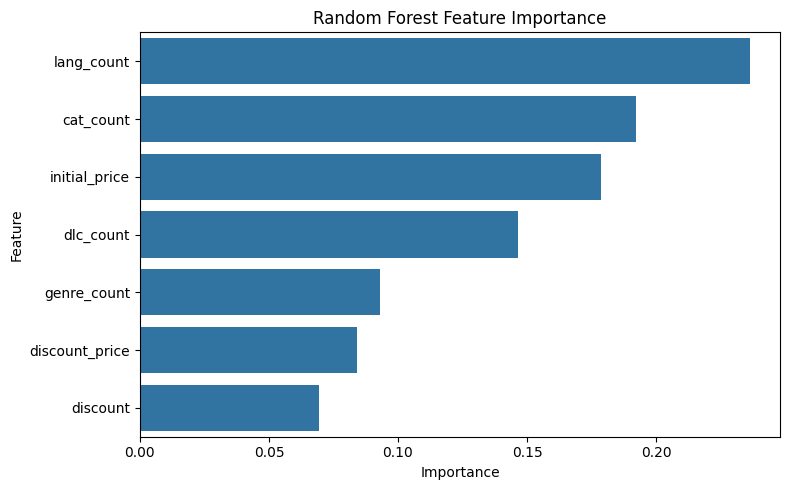

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="importance", y="feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()